# 08_cnn_lstm_ecg_classifier.ipynb

Goal: Build and compare a CNN-only baseline vs CNN-LSTM on the 5,000-record
PTB-XL development subset. This is the MVP/architecture-debugging phase.

CRITICAL: PTB-XL has repeat patients (same person, multiple ECG visits).
All train/val/test splits in this notebook are PATIENT-GROUPED
(GroupShuffleSplit on patient_id), never plain random-row splits.
This prevents a patient's ECG "fingerprint" from leaking across splits.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

plt.style.use("ggplot")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files
uploaded = files.upload()
# Upload: 07_X_ecg.npy, 07_y_ecg.npy, 07_patient_ids.npy
X_ecg = np.load("07_X_ecg.npy")
y_ecg = np.load("07_y_ecg.npy")
patient_ids = np.load("07_patient_ids.npy", allow_pickle=True)

print("X shape:", X_ecg.shape)   # expect (5000, 1000, 12)
print("y shape:", y_ecg.shape)
print("Unique patients:", len(np.unique(patient_ids)), "out of", len(patient_ids), "records")

Saving 07_patient_ids.npy to 07_patient_ids.npy
Saving 07_X_ecg.npy to 07_X_ecg.npy
Saving 07_y_ecg.npy to 07_y_ecg.npy
X shape: (5000, 1000, 12)
y shape: (5000,)
Unique patients: 4807 out of 5000 records


In [3]:
from sklearn.model_selection import GroupShuffleSplit

# Step 1: split off the test set (20%), grouped by patient
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_ecg, y_ecg, groups=patient_ids))

X_train_val, X_test = X_ecg[train_val_idx], X_ecg[test_idx]
y_train_val, y_test = y_ecg[train_val_idx], y_ecg[test_idx]
patients_train_val = patient_ids[train_val_idx]

# Step 2: split train_val into train (75%) and val (25%) -> overall 60/20/20
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=patients_train_val))

X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

print("Train:", X_train.shape, "  Val:", X_val.shape, "  Test:", X_test.shape)
print("Train label balance:", np.bincount(y_train))
print("Val label balance:  ", np.bincount(y_val))
print("Test label balance: ", np.bincount(y_test))

Train: (3007, 1000, 12)   Val: (1000, 1000, 12)   Test: (993, 1000, 12)
Train label balance: [1286 1721]
Val label balance:   [425 575]
Test label balance:  [408 585]


In [4]:
train_patients = set(patient_ids[train_val_idx][train_idx])
val_patients = set(patient_ids[train_val_idx][val_idx])
test_patients = set(patient_ids[test_idx])

print("Train ∩ Val overlap:", len(train_patients & val_patients))
print("Train ∩ Test overlap:", len(train_patients & test_patients))
print("Val ∩ Test overlap:", len(val_patients & test_patients))

Train ∩ Val overlap: 0
Train ∩ Test overlap: 0
Val ∩ Test overlap: 0


In [5]:
from tensorflow.keras import layers, models, callbacks

def build_cnn(input_shape):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=7, activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])  # (1000, 12)
cnn_model = build_cnn(input_shape)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 994, 32)        │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 994, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 497, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 493, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 493, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 244, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 244, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,945 (183.38 KB)

 Trainable params: 46,497 (181.63 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.7845 - auc: 0.8664 - loss: 0.4512 - val_accuracy: 0.6370 - val_auc: 0.8810 - val_loss: 0.6108
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8274 - auc: 0.9066 - loss: 0.3760 - val_accuracy: 0.7310 - val_auc: 0.9087 - val_loss: 0.4998
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8537 - auc: 0.9238 - loss: 0.3440 - val_accuracy: 0.8240 - val_auc: 0.9039 - val_loss: 0.3854
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8597 - auc: 0.9285 - loss: 0.3280 - val_accuracy: 0.8280 - val_auc: 0.9102 - val_loss: 0.3828
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8683 - auc: 0.9368 - loss: 0.3101 - val_accuracy: 0.8350 - val_auc: 0.9186 - val_loss: 0.3672
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8693 - auc: 0.9398 - loss: 0.3043 - val_accuracy: 0.8370 - val_auc: 0.9167 - val_loss: 0.3595
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/ste

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

CNN Baseline
Accuracy : 0.8308
Precision: 0.8854
Recall   : 0.8188
F1 Score : 0.8508
AUC      : 0.9162

               precision    recall  f1-score   support

           0       0.77      0.85      0.80       408
           1       0.89      0.82      0.85       585

    accuracy                           0.83       993
   macro avg       0.83      0.83      0.83       993
weighted avg       0.84      0.83      0.83       993



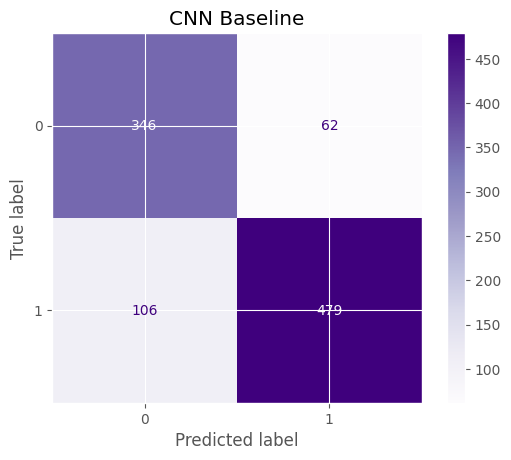

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

def evaluate_ecg_model(model, X_test, y_test, model_name, results_dict):
    probs = model.predict(X_test).flatten()
    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results_dict[model_name] = {
        "Accuracy": round(acc, 4), "Precision": round(prec, 4),
        "Recall": round(rec, 4), "F1 Score": round(f1, 4), "AUC": round(auc, 4)
    }

    print(f"\n{'='*50}\n{model_name}\n{'='*50}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print("\n", classification_report(y_test, preds))

    ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Purples")
    plt.title(model_name)
    plt.show()

    return probs

ecg_results = {}
cnn_probs = evaluate_ecg_model(cnn_model, X_test, y_test, "CNN Baseline", ecg_results)

In [8]:
def build_cnn_lstm(input_shape):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=7, activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.LSTM(64, return_sequences=False),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

cnn_lstm_model = build_cnn_lstm(input_shape)
cnn_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 994, 32)        │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 994, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 497, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 493, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 493, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,657 (197.88 KB)

 Trainable params: 50,465 (197.13 KB)

 Non-trainable params: 192 (768.00 B)

In [14]:
def build_cnn_lstm_v2(input_shape):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=7, activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.LSTM(64, return_sequences=False),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

cnn_lstm_v2_model = build_cnn_lstm_v2(input_shape)
cnn_lstm_v2_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 994, 32)        │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 994, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 497, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 493, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 493, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 244, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 244, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 122, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,257 (360.38 KB)

 Trainable params: 91,809 (358.63 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
cnn_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop_lstm = callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)

history_cnn_lstm = cnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6887 - auc: 0.7554 - loss: 0.5766 - val_accuracy: 0.7450 - val_auc: 0.8224 - val_loss: 0.5414
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7762 - auc: 0.8493 - loss: 0.4679 - val_accuracy: 0.6940 - val_auc: 0.8163 - val_loss: 0.5454
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7988 - auc: 0.8737 - loss: 0.4332 - val_accuracy: 0.7920 - val_auc: 0.8712 - val_loss: 0.4321
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8287 - auc: 0.8999 - loss: 0.3840 - val_accuracy: 0.8120 - val_auc: 0.8770 - val_loss: 0.4428
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8390 - auc: 0.9058 - loss: 0.3728 - val_accuracy: 0.8080 - val_auc: 0.8824 - val_loss: 0.4240
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8407 - auc: 0.9114 - loss: 0.3701 - val_accuracy: 0.8130 - val_auc: 0.8812 - val_loss: 0.4288
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms

In [15]:
cnn_lstm_v2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop_lstm_v2 = callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)

history_cnn_lstm_v2 = cnn_lstm_v2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_lstm_v2],
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7133 - auc: 0.7914 - loss: 0.5441 - val_accuracy: 0.6480 - val_auc: 0.8454 - val_loss: 0.5868
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8078 - auc: 0.8723 - loss: 0.4342 - val_accuracy: 0.8040 - val_auc: 0.8678 - val_loss: 0.4430
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8264 - auc: 0.8920 - loss: 0.4020 - val_accuracy: 0.7960 - val_auc: 0.8725 - val_loss: 0.4533
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8440 - auc: 0.9160 - loss: 0.3628 - val_accuracy: 0.8180 - val_auc: 0.8844 - val_loss: 0.4443
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8510 - auc: 0.9216 - loss: 0.3446 - val_accuracy: 0.8160 - val_auc: 0.8903 - val_loss: 0.4151
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8570 - auc: 0.9301 - loss: 0.3270 - val_accuracy: 0.8120 - val_auc: 0.8888 - val_loss: 0.4214
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

CNN-LSTM
Accuracy : 0.8077
Precision: 0.8569
Recall   : 0.8085
F1 Score : 0.8320
AUC      : 0.8785

               precision    recall  f1-score   support

           0       0.75      0.81      0.78       408
           1       0.86      0.81      0.83       585

    accuracy                           0.81       993
   macro avg       0.80      0.81      0.80       993
weighted avg       0.81      0.81      0.81       993



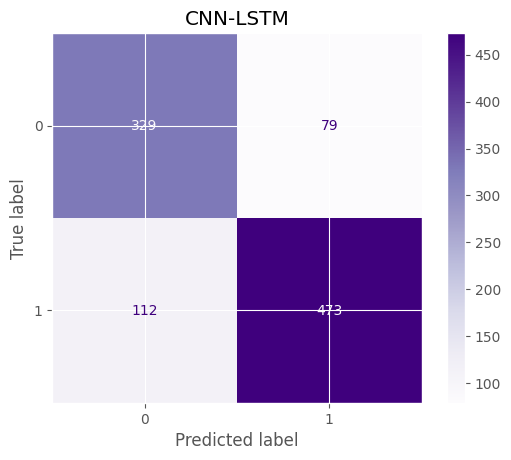

In [10]:
cnn_lstm_probs = evaluate_ecg_model(cnn_lstm_model, X_test, y_test, "CNN-LSTM", ecg_results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

CNN-LSTM (3-conv)
Accuracy : 0.8177
Precision: 0.8826
Recall   : 0.7966
F1 Score : 0.8374
AUC      : 0.8893

               precision    recall  f1-score   support

           0       0.74      0.85      0.79       408
           1       0.88      0.80      0.84       585

    accuracy                           0.82       993
   macro avg       0.81      0.82      0.82       993
weighted avg       0.83      0.82      0.82       993



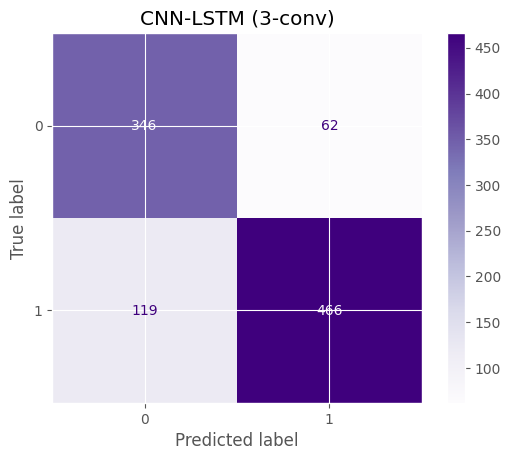

In [16]:
cnn_lstm_v2_probs = evaluate_ecg_model(cnn_lstm_v2_model, X_test, y_test, "CNN-LSTM (3-conv)", ecg_results)

              Accuracy  Precision  Recall  F1 Score     AUC
CNN Baseline    0.8308     0.8854  0.8188    0.8508  0.9162
CNN-LSTM        0.8077     0.8569  0.8085    0.8320  0.8785


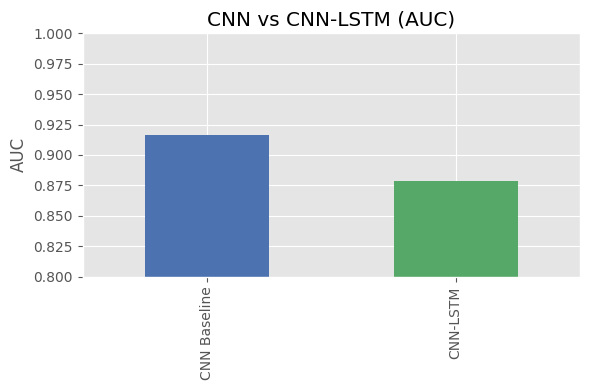

In [11]:
comparison_ecg = pd.DataFrame(ecg_results).T
comparison_ecg = comparison_ecg.sort_values(by="AUC", ascending=False)
print(comparison_ecg)

comparison_ecg["AUC"].plot(kind="bar", figsize=(6,4), title="CNN vs CNN-LSTM (AUC)", color=["#4C72B0","#55A868"])
plt.ylabel("AUC")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig("08_cnn_vs_cnnlstm_comparison.png", dpi=150)
plt.show()

In [17]:
comparison_ecg_v2 = pd.DataFrame(ecg_results).T
comparison_ecg_v2 = comparison_ecg_v2.sort_values(by="AUC", ascending=False)
print(comparison_ecg_v2)

                   Accuracy  Precision  Recall  F1 Score     AUC
CNN Baseline         0.8308     0.8854  0.8188    0.8508  0.9162
CNN-LSTM (3-conv)    0.8177     0.8826  0.7966    0.8374  0.8893
CNN-LSTM             0.8077     0.8569  0.8085    0.8320  0.8785


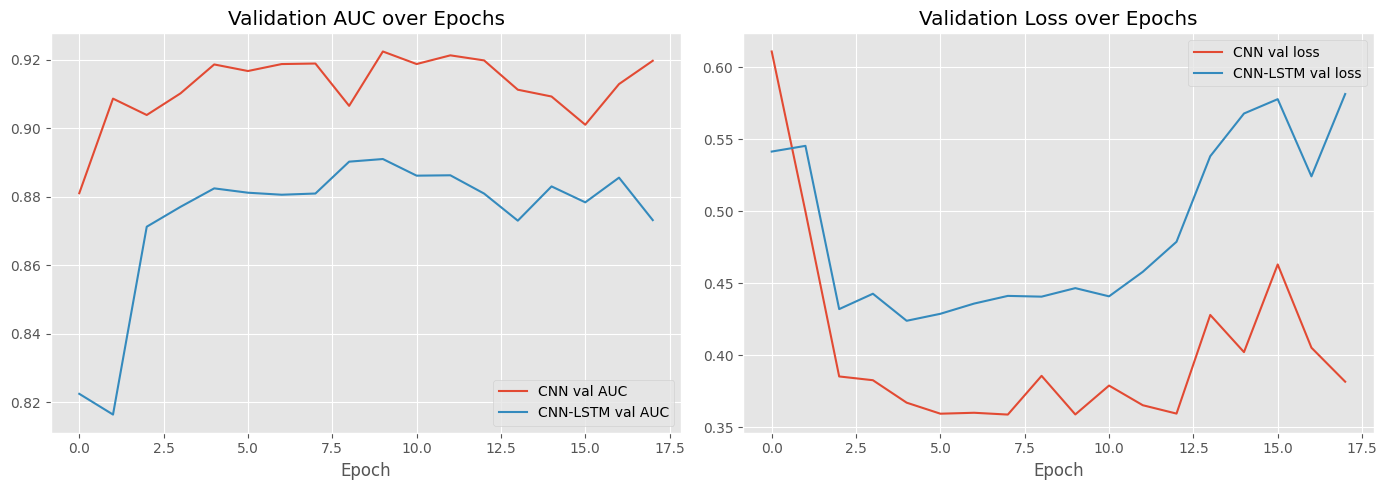

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_cnn.history["val_auc"], label="CNN val AUC")
axes[0].plot(history_cnn_lstm.history["val_auc"], label="CNN-LSTM val AUC")
axes[0].set_title("Validation AUC over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_cnn.history["val_loss"], label="CNN val loss")
axes[1].plot(history_cnn_lstm.history["val_loss"], label="CNN-LSTM val loss")
axes[1].set_title("Validation Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("08_training_curves_comparison.png", dpi=150)
plt.show()

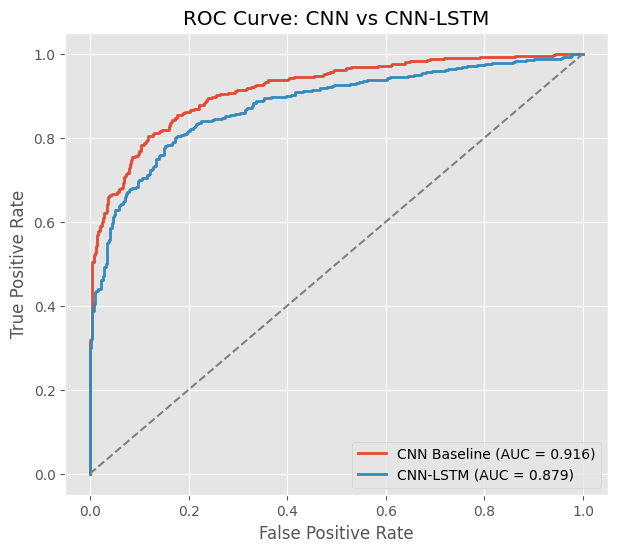

In [13]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))
for name, probs in [("CNN Baseline", cnn_probs), ("CNN-LSTM", cnn_lstm_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: CNN vs CNN-LSTM")
plt.legend()
plt.grid(True)
plt.savefig("08_roc_curve_ecg.png", dpi=150)
plt.show()

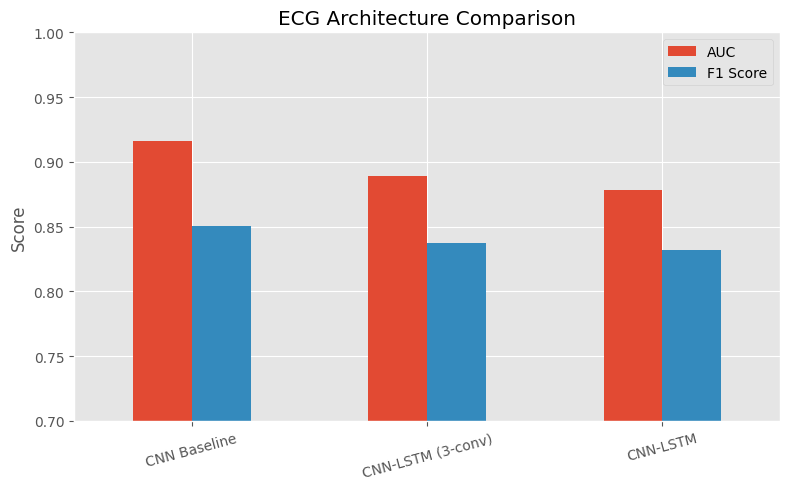

In [18]:
comparison_ecg_v2[["AUC","F1 Score"]].plot(kind="bar", figsize=(8,5), title="ECG Architecture Comparison")
plt.ylabel("Score")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("08_final_architecture_comparison.png", dpi=150)
plt.show()

In [19]:
comparison_ecg_v2.to_csv("08_ecg_model_comparison.csv", index=True)

# Lock in CNN as the official ECG architecture
cnn_model.save("08_cnn_ecg_model.keras")

print("Final ECG architecture locked: CNN Baseline")
print(comparison_ecg_v2.loc["CNN Baseline"])

Final ECG architecture locked: CNN Baseline
Accuracy     0.8308
Precision    0.8854
Recall       0.8188
F1 Score     0.8508
AUC          0.9162
Name: CNN Baseline, dtype: float64


In [20]:
# ==========================================
# Save Results
# ==========================================

comparison_ecg_v2.to_csv(
    "08_ecg_model_comparison.csv",
    index=True
)

# Save training histories
pd.DataFrame(history_cnn.history).to_csv(
    "08_cnn_training_history.csv",
    index=False
)

pd.DataFrame(history_cnn_lstm.history).to_csv(
    "08_cnn_lstm_training_history.csv",
    index=False
)

pd.DataFrame(history_cnn_lstm_v2.history).to_csv(
    "08_cnn_lstm3conv_training_history.csv",
    index=False
)

# Save best model
cnn_model.save("08_cnn_ecg_model.keras")

print("Final ECG architecture locked: CNN Baseline")
print(comparison_ecg_v2.loc["CNN Baseline"])

Final ECG architecture locked: CNN Baseline
Accuracy     0.8308
Precision    0.8854
Recall       0.8188
F1 Score     0.8508
AUC          0.9162
Name: CNN Baseline, dtype: float64


In [21]:
from google.colab import files

download_files = [

    # Metrics
    "08_ecg_model_comparison.csv",
    "08_cnn_training_history.csv",
    "08_cnn_lstm_training_history.csv",
    "08_cnn_lstm3conv_training_history.csv",

    # Model
    "08_cnn_ecg_model.keras",

    # Plots
    "08_cnn_vs_cnnlstm_comparison.png",
    "08_training_curves_comparison.png",
    "08_roc_curve_ecg.png",
    "08_final_architecture_comparison.png"
]

for f in download_files:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>